In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# train.csv debe estar en la misma carpeta que este notebook
df = pd.read_csv("train.csv", parse_dates=["date"])

print("Filas:", len(df))
print("Rango de fechas:", df["date"].min().date(),
      "a", df["date"].max().date())
print("Tiendas:", df["store"].nunique(), "| Productos:", df["item"].nunique())
df.head()


Filas: 913000
Rango de fechas: 2013-01-01 a 2017-12-31
Tiendas: 10 | Productos: 50


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
tienda = 1
items = [1, 2, 3, 4, 5]

d = df[(df["store"] == tienda) & (df["item"].isin(items))].copy()
d = d.set_index("date")

# ventas semanales por producto
semanal = (d.groupby("item")["sales"]
           .resample("W").sum()
           .reset_index())

print("Semanas por producto:", semanal.groupby("item").size().iloc[0])
semanal.head()


Semanas por producto: 261


,item,date,sales
0,1,2013-01-06,73
1,1,2013-01-13,66
2,1,2013-01-20,80
3,1,2013-01-27,70
4,1,2013-02-03,86


In [ ]:
FEATURES = ["lag1", "lag2", "lag4", "tendencia", "sin52", "cos52"]


def construir_features(serie):
    t = pd.DataFrame({"y": serie})
    t["lag1"] = t["y"].shift(1)
    t["lag2"] = t["y"].shift(2)
    t["lag4"] = t["y"].shift(4)
    t["tendencia"] = np.arange(len(t))
    semana = np.arange(len(t)) % 52
    t["sin52"] = np.sin(2 * np.pi * semana / 52)
    t["cos52"] = np.cos(2 * np.pi * semana / 52)
    return t


def pronostico_hw(serie, h):
    modelo = ExponentialSmoothing(serie, trend="add", seasonal="add",
                                  seasonal_periods=52).fit()
    return modelo.forecast(h).values


def pronostico_regresion(serie, h):
    datos = construir_features(serie).dropna()
    X = datos[FEATURES].values
    y = datos["y"].values
    modelo = LinearRegression().fit(X, y)

    historia = list(serie)
    preds = []
    for paso in range(h):
        n = len(historia)
        semana = n % 52
        x = [[historia[-1], historia[-2], historia[-4], n,
              np.sin(2 * np.pi * semana / 52), np.cos(2 * np.pi * semana / 52)]]
        p = modelo.predict(x)[0]
        p = max(p, 0)                 # las ventas no pueden ser negativas
        preds.append(p)
        # uso mi propia prediccion como siguiente lag
        historia.append(p)
    return np.array(preds)


In [5]:
def wape(real, pred):
    return np.abs(real - pred).sum() / np.abs(real).sum() * 100


In [6]:
H = 8
resultados = []

for item in items:
    serie = semanal[semanal["item"] == item]["sales"].reset_index(drop=True)
    train = serie[:-H]
    test = serie[-H:].values

    pred_hw = pronostico_hw(train, H)
    pred_reg = pronostico_regresion(train, H)

    resultados.append({
        "item": item,
        "WAPE_HW": round(wape(test, pred_hw), 1),
        "WAPE_Reg": round(wape(test, pred_reg), 1),
    })

tabla = pd.DataFrame(resultados)
tabla["mejor"] = np.where(tabla["WAPE_HW"] <= tabla["WAPE_Reg"],
                          "Holt-Winters", "Regresion")
tabla


,item,WAPE_HW,WAPE_Reg,mejor
0,1,7.8,12.5,Holt-Winters
1,2,7.4,13.0,Holt-Winters
2,3,6.4,10.8,Holt-Winters
3,4,9.2,17.3,Holt-Winters
4,5,7.2,13.6,Holt-Winters


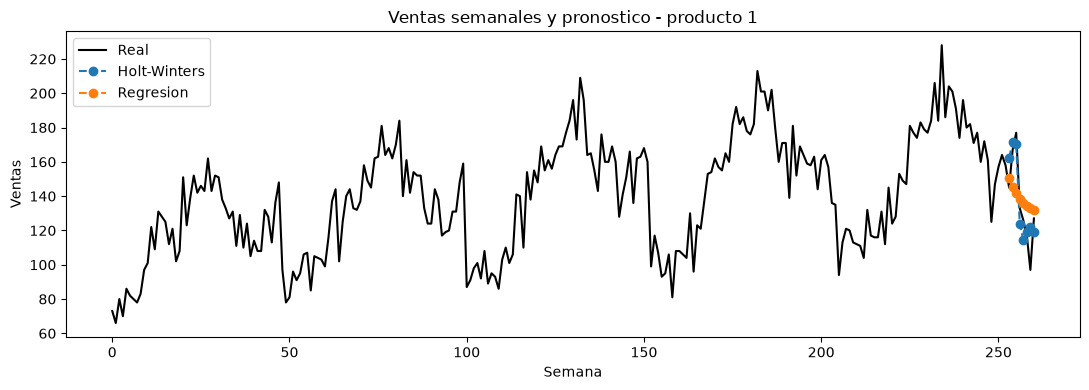

In [ ]:
item = 1
serie = semanal[semanal["item"] == item]["sales"].reset_index(drop=True)
train = serie[:-H]

pred_hw = pronostico_hw(train, H)
pred_reg = pronostico_regresion(train, H)
x_fut = range(len(train), len(serie))

plt.figure(figsize=(11, 4))
plt.plot(range(len(serie)), serie.values, color="black", label="Real")
plt.plot(x_fut, pred_hw, "--", marker="o", label="Holt-Winters")
plt.plot(x_fut, pred_reg, "--", marker="o", label="Regresion")
plt.title(f"Ventas semanales y pronostico - producto {item}")
plt.xlabel("Semana")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()
